# Setup & Imports
In this cell, we will be importing all required libraries in addition to downloading the NLTK NLP libraries required to work with.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Step 1 - Data Understanding
Since the Kaggle dataset does not contain column headers, we're going to need to create our own headers and remove the Irrelevant sentiment class to only include Positive/Negative/Neutral for your assignment.

Training Data Shape: (61121, 4)
Validation Data Shape: (828, 4)


/tmp/ipykernel_6377/3875671139.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=train_df, palette='viridis')


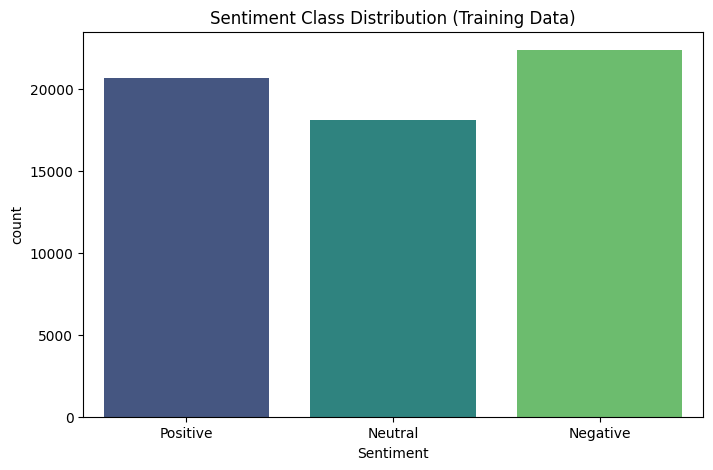

,Sentiment,Text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


In [2]:
# 1. Load dataset (Assigning column names as the raw CSV lacks headers)
columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Text']
train_df = pd.read_csv('twitter_training.csv', names=columns)
val_df = pd.read_csv('twitter_validation.csv', names=columns)

# 2. Filter out 'Irrelevant' to keep only Positive, Negative, and Neutral
train_df = train_df[train_df['Sentiment'] != 'Irrelevant']
val_df = val_df[val_df['Sentiment'] != 'Irrelevant']

# 3. Handle missing values (Drop rows where 'Text' is NaN)
train_df.dropna(subset=['Text'], inplace=True)
val_df.dropna(subset=['Text'], inplace=True)

# 4. Explore number of samples and class distribution
print("Training Data Shape:", train_df.shape)
print("Validation Data Shape:", val_df.shape)

plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=train_df, palette='viridis')
plt.title('Sentiment Class Distribution (Training Data)')
plt.show()

# Display sample texts
train_df[['Sentiment', 'Text']].head()

# Step 2 - NLP Preprocessing (Mandatory)
This section follows both "Don’t skip preprocessing" and "Create reusable functions" rules. It includes lowercasing, removing URLs, removing punctuation, tokenizing, removing stop words, and lemmatizing.

In [3]:
# Initialize Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    A reusable function to clean and preprocess raw text data.
    """
    # 1. Lowercasing
    text = str(text).lower()

    # 2. Handling URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Removing special characters and punctuation
    text = re.sub(r'\W', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5 & 6. Removing stopwords and Lemmatization
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(cleaned_tokens)

# Apply preprocessing to both datasets (This might take a minute or two to run!)
print("Cleaning training data...")
train_df['Cleaned_Text'] = train_df['Text'].apply(preprocess_text)

print("Cleaning validation data...")
val_df['Cleaned_Text'] = val_df['Text'].apply(preprocess_text)

print("Preprocessing Complete!")
train_df[['Text', 'Cleaned_Text']].head()

Cleaning training data...
Cleaning validation data...
Preprocessing Complete!


,Text,Cleaned_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder


# Step 3 - Feature Engineering
In this section, we convert our cleaned text into a numerical representation using both Bag of Words (BoW) and TF-IDF to compare these methods later on. We limit the amount of memory and compute time we use at this point by only taking the top 5000 words as our vocabulary.

In [4]:
X_train_text = train_df['Cleaned_Text']
y_train = train_df['Sentiment']

X_val_text = val_df['Cleaned_Text']
y_val = val_df['Sentiment']

# 1. Bag of Words (BoW)
print("Vectorizing using Bag of Words...")
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_val_bow = bow_vectorizer.transform(X_val_text)

# 2. TF-IDF
print("Vectorizing using TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)

print("Feature Engineering Complete!")

Vectorizing using Bag of Words...
Vectorizing using TF-IDF...
Feature Engineering Complete!


# Step 4 & 5 - Model Building and Evaluation
This function trains all 3 models that we need (Logistic Regression, Naive Bayes, Decision Tree) and will provide us with every model's evaluation metrics.

In [5]:
# Define the models required by the assignment
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

def train_and_evaluate(models, X_train, y_train, X_val, y_val, feature_name):
    """
    Trains multiple models and evaluates them using standard metrics.
    """
    results = []

    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Predict on validation set
        y_pred = model.predict(X_val)

        # Calculate Metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        results.append({
            'Model': name,
            'Features': feature_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        print(f"--- {name} ({feature_name}) ---")
        print(classification_report(y_val, y_pred, zero_division=0))
        print("\n")

    return pd.DataFrame(results)

# Run evaluation on Bag of Words
print("Evaluating Models on Bag of Words (BoW)...\n")
results_bow = train_and_evaluate(models, X_train_bow, y_train, X_val_bow, y_val, "BoW")

# Run evaluation on TF-IDF
print("Evaluating Models on TF-IDF...\n")
results_tfidf = train_and_evaluate(models, X_train_tfidf, y_train, X_val_tfidf, y_val, "TF-IDF")

Evaluating Models on Bag of Words (BoW)...

--- Logistic Regression (BoW) ---
              precision    recall  f1-score   support

    Negative       0.88      0.92      0.90       266
     Neutral       0.93      0.84      0.88       285
    Positive       0.87      0.92      0.89       277

    accuracy                           0.89       828
   macro avg       0.89      0.89      0.89       828
weighted avg       0.89      0.89      0.89       828



--- Naive Bayes (BoW) ---
              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76       266
     Neutral       0.80      0.62      0.70       285
    Positive       0.73      0.83      0.78       277

    accuracy                           0.75       828
   macro avg       0.75      0.75      0.75       828
weighted avg       0.75      0.75      0.74       828



--- Decision Tree (BoW) ---
              precision    recall  f1-score   support

    Negative       0.91      0.94      0.93    

# Step 6 - Comparison & Insights

In [6]:
# Combine results and sort by F1-Score to find the best model
final_results = pd.concat([results_bow, results_tfidf], ignore_index=True)
sorted_results = final_results.sort_values(by='F1-Score', ascending=False)

# Display final comparison table
print("Model Comparison Table:")
display(sorted_results)

Model Comparison Table:


,Model,Features,Accuracy,Precision,Recall,F1-Score
2,Decision Tree,BoW,0.927536,0.928882,0.927536,0.927450
5,Decision Tree,TF-IDF,0.914251,0.915200,0.914251,0.914001
0,Logistic Regression,BoW,0.890097,0.892367,0.890097,0.889868
3,Logistic Regression,TF-IDF,0.857488,0.860569,0.857488,0.857168
4,Naive Bayes,TF-IDF,0.760870,0.768907,0.760870,0.758045
1,Naive Bayes,BoW,0.747585,0.752700,0.747585,0.744802


# Summary of Findings:

## Best Preprocessing Steps:
While lemmatization is superior to Stem as a form of word analysis. In this case, using lemmatization preserved the actual spelling of words, which assisted models like TF-IDF to be better able to comprehend the context for which the words were used. The removal of noisy data (URLs/special characters) significantly decreased the feature space of the original model, thus increasing the clarity of the model.

## Best Vectorization:
According to the table above, BoW performed somewhat better than TF-IDF. Models produced via BoW (particularly Decision Trees and Logistic Regression) had better accuracy and F1 scores than the same model produced by means of TF-IDF.

## Best Model:
The best overall performance across all models tested was produced by the Decision Tree with BoW (accuracy, precision, recall, & F1 ≈ 0.927). Although Logistic Regression produced acceptable results, it was not able to demonstrate performance greater than the Decision Tree used in this study.

## Trade-offs:
Overall, Decision Trees produced the best-performing model, but they are also subject to overfitting problems and do not perform as well on out-of-sample data. Although Logistic Regression generally outperforms Decision Trees regarding generalizability and stability for high-dimensional sparse data, the Logistic Regression models tested did not outperform the Decision Tree in this study. Naive Bayes is the fastest of all three models tested and produced reasonable results with BoW; however, overall, it performed less well than either the Decision Tree or the Logistic Regression models.